
Congrats....again! Based off the amazing work you did on the classification model, you've been promoted to chief of all data scientists in Hollywood, your a total celebrity....among data scientists :).  

Your boss, head of the studio, has now asked you to build a model to predict gross revenue in order to help them decide which movies to invest in.

Once again, you would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so...you leverage work you've done in the past to get the job done....you're a data scientist after all! 

In [31]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split,RepeatedKFold,GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor, export_graphviz 
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import get_scorer_names

In [32]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

## 2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [33]:
movie_metadata.info()
# For categorical variables
cat = movie_metadata.select_dtypes(include=['object']).columns
movie_metadata[cat] = movie_metadata[cat].astype('category')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [34]:
#import the encoders
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

In [35]:
## encode directors
dir_val=movie_metadata['director_name'].value_counts().nlargest(10).index

#print(dir_val)

movie_metadata['director_name']=movie_metadata['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')

#print(movie_metadata['director_name'].value_counts())

#one hot encode
dir_encoded = encoder.fit_transform(movie_metadata[["director_name"]])
dir_1h = pd.DataFrame(
    dir_encoded,
    columns=encoder.get_feature_names_out(['director_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['director_name']), dir_1h], axis=1)

#print(movie_metadata["director_name"].value_counts())

In [36]:
## encode title_year
movie_metadata["title_year"] = movie_metadata["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)

title_encoded=encoder.fit_transform(movie_metadata[["title_year"]])
title_1h = pd.DataFrame(
    title_encoded,
    columns=encoder.get_feature_names_out(['title_year']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['title_year']), title_1h], axis=1)

In [37]:
## encode first actor
act_10 = list(movie_metadata['actor_1_name'].value_counts().nlargest(10).index)

#print(act_10)

# Create a new column so you can compare after
movie_metadata['actor_1_name'] = movie_metadata['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)

#print(movie_metadata['actor_1_name'].value_counts())

act_encoded = encoder.fit_transform(movie_metadata[["actor_1_name"]])
act_1h = pd.DataFrame(
    act_encoded,
    columns=encoder.get_feature_names_out(['actor_1_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['actor_1_name']), act_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [38]:
## encode country
count10=movie_metadata['country'].value_counts().nlargest(10)
#print(count10)

movie_metadata['country']=movie_metadata['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata['country'].value_counts())

count_encoded = encoder.fit_transform(movie_metadata[["country"]])
count_1h = pd.DataFrame(
    count_encoded,
    columns=encoder.get_feature_names_out(['country']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['country']), count_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [39]:
## encode content rating
#print(movie_metadata['content_rating'].value_counts())
movie_metadata['content_rating']=movie_metadata['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')

#print(movie_metadata['content_rating'].value_counts())

cont_encoded = encoder.fit_transform(movie_metadata[["content_rating"]])
cont_1h = pd.DataFrame(
    cont_encoded,
    columns=encoder.get_feature_names_out(['content_rating']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['content_rating']), cont_1h], axis=1)

In [40]:
# encode language
lang10=movie_metadata['language'].value_counts().nlargest(10)
#print(lang10)

movie_metadata['language']=movie_metadata['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata['language'].value_counts())

#movie_metadata[['language']]=OneHotEncoder().fit_transform(movie_metadata[['language']])
#print(movie_metadata['language'].value_counts())

language_encoded = encoder.fit_transform(movie_metadata[['language']])

language_1h = pd.DataFrame(
    language_encoded,
    columns=encoder.get_feature_names_out(['language']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['language']), language_1h], axis=1)

In [41]:
# encode color
#print(movie_metadata['color'].value_counts())
movie_metadata['color']=movie_metadata['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')

#movie_metadata[['color']]=OneHotEncoder().fit_transform(movie_metadata[['color']])
#print(movie_metadata['color'].value_counts())

color_encoded = encoder.fit_transform(movie_metadata[['color']])

color_1h = pd.DataFrame(
    color_encoded,
    columns=encoder.get_feature_names_out(['color']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['color']), color_1h], axis=1)

In [42]:
# Categorize imdb_score into three classes
movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(
    lambda x: "high" if x >= 8.0 else "average" if x > 6.0 else "low"
)

#print(movie_metadata["imdb_score"].value_counts())

movie_metadata["imdb_score"] = OrdinalEncoder().fit_transform(movie_metadata[['imdb_score']])

#print(movie_metadata["imdb_score"].value_counts())

## 3 Check for missing variables and correct as needed.

In [43]:
print(movie_metadata.isnull().sum())
movie_metadata = movie_metadata.dropna()
movie_metadata = movie_metadata.drop(['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'], axis=1)

num_critic_for_reviews           50
duration                         15
director_facebook_likes         104
actor_3_facebook_likes           23
actor_2_name                     13
actor_1_facebook_likes            7
gross                           884
genres                            0
movie_title                       0
num_voted_users                   0
cast_total_facebook_likes         0
actor_3_name                     23
facenumber_in_poster             13
plot_keywords                   153
movie_imdb_link                   0
num_user_for_reviews             21
budget                          492
actor_2_facebook_likes           13
imdb_score                        0
aspect_ratio                    329
movie_facebook_likes              0
director_name_Famous              0
director_name_Other               0
director_name_nan                 0
title_year_middle                 0
title_year_new                    0
title_year_old                    0
actor_1_name_Famous         

## 4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

## 5 Determine the variance of the target variable, is it normally distributed? If not, you may want to transform the target variable. Why might this be important?

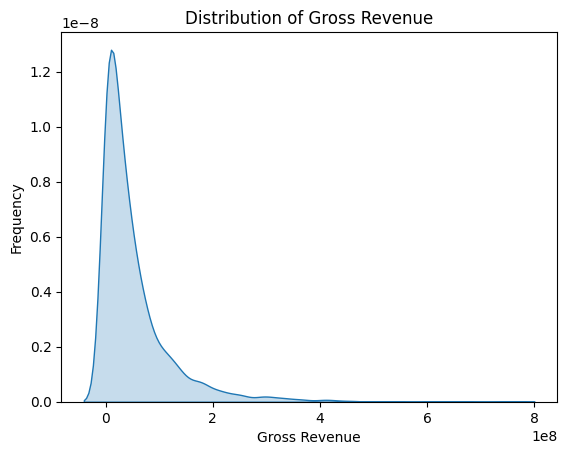

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(movie_metadata, x ='gross', fill=True, common_norm=False)
plt.title('Distribution of Gross Revenue')
plt.xlabel('Gross Revenue')
plt.ylabel('Frequency')
plt.show()

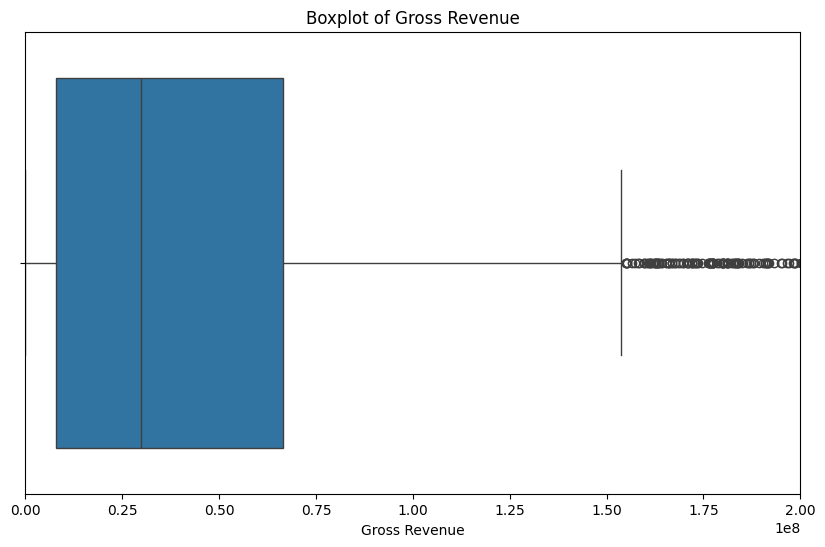

Number of outliers:  295


In [45]:
# check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=movie_metadata['gross'])
plt.title('Boxplot of Gross Revenue')
plt.xlabel('Gross Revenue')
plt.xlim(0, 2e8)
plt.show()

# count the number of outliers
outliers = movie_metadata[(movie_metadata['gross'] > 1.5e8)]
print("Number of outliers: ", len(outliers))

In [46]:
movie_metadata = movie_metadata[movie_metadata['gross'] <= 1.5e8]

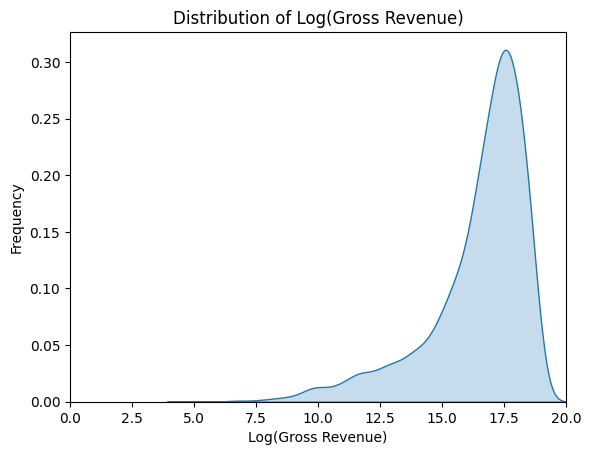

In [47]:
movie_metadata['Log_Gross'] = np.log(movie_metadata['gross'])
# Drop gross revenue column
movie_metadata = movie_metadata.drop(columns=['gross'])
# Check the distribution of the target variable
sns.kdeplot(movie_metadata, x ='Log_Gross', fill=True, common_norm=False)
plt.title('Distribution of Log(Gross Revenue)')
plt.xlabel('Log(Gross Revenue)')
plt.ylabel('Frequency')
plt.xlim(0, 20)
plt.show()

## 6 Split your data into test, tune, and train. (80/10/10)

In [52]:
X = movie_metadata.drop('Log_Gross', axis=1)
y = movie_metadata['Log_Gross']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test, y_test, train_size=0.50, random_state=49)

## 7 Create the kfold object for cross validation.

In [54]:
kf = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)
param={
    "max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    #"splitter":["best","random"],
    #"min_samples_leaf":[1,2,3,4,5,6,7,8,9,10],
    #"min_weight_fraction_leaf":[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
    #"max_features":["auto","log2","sqrt",None],
    #"max_leaf_nodes":[None,10,20,30,40,50,60,70,80,90] 
    #'min_impurity_decrease':[0.00005,0.0001,0.0002,0.0005,0.001,0.0015,0.002,0.005,0.01],
    #'ccp_alpha':[.001,.01,.1]
        }

## 8 Create the scoring metric (several measures) you will use to evaluate your model and the max depth hyperparameter.

In [55]:
print(get_scorer_names())  # find them
scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

## 9 Build the regression tree object. 

In [56]:
reg=DecisionTreeRegressor(random_state=30)
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')

## 10 Fit the model to the training data.

In [57]:
model = search.fit(X_train, y_train)

In [58]:
# best hyperparameters
print("Best Hyperparameters: ", model.best_params_)
# best score
print("Best Score: ", model.best_score_)

Best Hyperparameters:  {'max_depth': 4}
Best Score:  0.4350953890159104


## 11 Explore the results of the model. Print the output of the grid search. What is the best parameter and score?

In [64]:
# Print the results of the grid search
print(pd.DataFrame(model.cv_results_))

best=model.best_estimator_
print(best)

# Print the best hyperparameters
print(model.best_params_)

# Print the best score
print(model.best_score_)

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.012077      0.011937         0.006225        0.005350   
1        0.013849      0.003752         0.005398        0.003243   
2        0.018712      0.008804         0.004950        0.002622   
3        0.028667      0.013913         0.007888        0.007022   
4        0.027935      0.015198         0.005247        0.004093   
5        0.021973      0.003593         0.003229        0.000917   
6        0.053843      0.036069         0.018155        0.034210   
7        0.050515      0.044762         0.006181        0.006391   
8        0.035960      0.008967         0.003937        0.002453   
9        0.035297      0.004108         0.003493        0.001091   
10       0.069530      0.057622         0.009784        0.012142   
11       0.124954      0.049692         0.027001        0.029799   
12       0.084256      0.041184         0.009263        0.009845   
13       0.057407      0.035333         0.004131

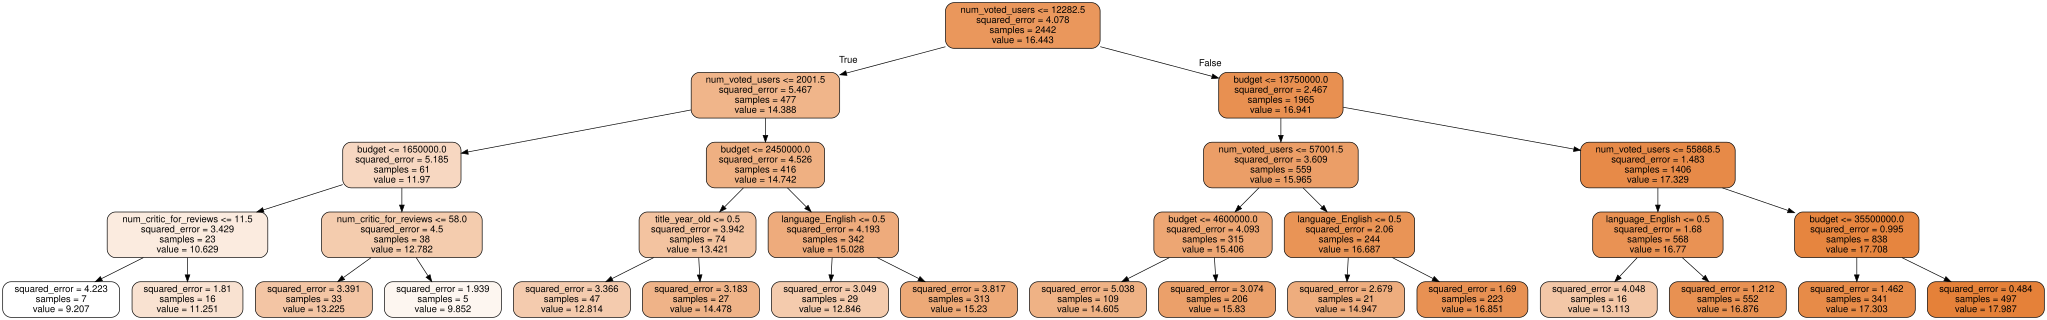

In [65]:
import graphviz

dot_data = export_graphviz(best, out_file=None,
               feature_names=X.columns,  # feature names from dataset
               filled=True, 
               rounded=True) 
               
graph = graphviz.Source(dot_data)
graph

## 12 Which variables appear to be contributing the most (variable importance)

In [66]:
varimp=pd.DataFrame(best.feature_importances_,index = X_train.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                              importance
num_voted_users                 0.665493
budget                          0.226445
language_English                0.085347
num_critic_for_reviews          0.013510
title_year_old                  0.009204
language_nan                    0.000000
language_Other                  0.000000
language_French                 0.000000
color_Black and White           0.000000
color_Color                     0.000000
actor_1_name_Famous             0.000000
content_rating_R                0.000000
content_rating_PG-13            0.000000
content_rating_Other            0.000000
country_nan                     0.000000
country_Other                   0.000000
country_Big Country Producer    0.000000
actor_1_name_nan                0.000000
actor_1_name_Other              0.000000
content_rating_nan              0.000000
title_year_new                  0.000000
duration                        0.000000
title_year_middle               0.000000
director_name_na

## 13 Create a model object using the best model hyperparameter value from the trained regression tree.

In [68]:
best=model.best_estimator_

## 14 Using the best model predict on the tune data and print out the results.

In [70]:
y_pred = best.predict(X_tune)
print(y_pred)

[16.85099957 15.23004927 15.23004927 17.98652046 15.23004927 16.85099957
 17.98652046 16.85099957 16.87624998 15.83028438 15.23004927 17.30320955
 16.87624998 12.84635921 17.98652046 13.22549612 17.98652046 12.813649
 16.87624998 16.87624998 17.98652046 15.23004927 17.30320955 16.87624998
 17.98652046 16.87624998 17.30320955 17.98652046 15.83028438 17.98652046
  9.20658391 14.47827683 16.87624998 15.83028438 17.98652046 17.98652046
 14.60525022 17.98652046 17.30320955 14.60525022 15.23004927 17.30320955
 17.30320955 16.87624998 16.85099957 15.23004927 11.25071944 16.87624998
 17.98652046  9.20658391 16.87624998 17.98652046 16.85099957 17.98652046
 17.98652046 17.98652046 12.813649   17.30320955 16.87624998 16.87624998
 15.23004927 17.30320955 17.30320955 17.98652046 16.87624998 15.23004927
 16.87624998 17.98652046 17.98652046 12.813649   17.30320955 17.30320955
 15.23004927 14.94714379 12.84635921 15.23004927 16.87624998 17.30320955
 15.23004927 15.83028438 16.85099957 17.30320955 16.8

## 15 How does the model perform on the tune data as compared to the training data?

In [71]:
print(model.score(X_tune, y_tune))
print(model.score(X_train, y_train))

0.4177166471741045
0.5184246766351844


The model performs better on the training data because the model is trained on the training data.

## 16 What five movies are predicted to have the lowest gross revenue from the tune set?

In [ ]:
# Load movie metadata
movie_metadata = pd.read_csv("../data/movie_metadata.csv")
movie_metadata = movie_metadata.dropna()

# Get movie titles that match X_test rows
movie_metadata_aligned = movie_metadata.loc[movie_metadata.index.intersection(X_tune.index)].reset_index(drop=True)

# Get movie titles that match X_tune rows
movie_test = movie_metadata_aligned

# Attach titles and probabilities
X_tune_copy = movie_test['movie_title'].values
X_tune_copy['prob_high'] = y_probs

# Show top 3 movies by high-score probability
top_5 = X_tune_copy[['movie_title', 'prob_high']].sort_values(by='prob_high', ascending=False).head(5)

print("Top 5 Movies Based on Predicted Probability of High Score:")
print(top_5)

NameError: name 'X_tune_copy' is not defined

## 17 As a data scientist you are always looking to improve your results. What are some ideas you have to improve the model? Have you ask...WHAT IF?!

## 18 Experiment using your what if ideas (two is fine). Did the model improve? If so, how much? If not, what did you learn? (You don't need to include all the "what if" code just speak to what you tried and what you learned).

## 19 Use the best model to predict on the test data and print out the evaluation results.

## 20 Does the model perform well on the test data when compared to the training and tune data? Why or why not?

## 21 Where are the errors occurring in your predictions? Are they systematic or random? In either case, what are the implications of this?

## 22 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.